## Imports


In [1]:

import torch
import numpy as np
import pandas as pd
from pathlib import Path
import random
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

## Parameters

In [2]:
num_epochs = 50
sample_numbers = 10000
data_name = 'T500'
batch_size = 64
model_type = "cnn1d"   # <-- change to "lstm" to use the LSTM


# Paths
base_path = rf"D:\AIoT_project\data_sets\IEEE_dataPort\AES-{data_name}_power_Temp25C\AES-{data_name}_power_Temp25C"
trj_disabled = rf"\AES-{data_name}+TrojanDisabled_1\AES-{data_name}+TrojanDisabled_1"
trj_enabled = rf"\AES-{data_name}+TrojanTriggered_1\AES-{data_name}+TrojanTriggered_1"


## Load function

In [3]:
def load_aes_samples(folder: Path, label: int, num_samples: int):
    """
    Loads AES power trace CSV files from 'folder'.
    Appends class label to the end of each trace.
    """
    all_data = []
    for i in range(num_samples):
        file_path = folder / f"Sample_{i}.csv"
        data = pd.read_csv(file_path, header=None)
        trace = data[0].to_numpy(dtype=np.float32)
        labeled_trace = np.append(trace, label)
        all_data.append(labeled_trace)
    return np.array(all_data, dtype=np.float32)

## Load both classes

In [4]:


def load_class_data(folder_path, label, num_samples):
    data_folder = Path(folder_path)
    labeled_arrays = []
    for i in range(num_samples):
        file_path = data_folder / f"Sample_{i}.csv"
        data = pd.read_csv(file_path, header=None)
        array = data[0].to_numpy()
        labeled_array = np.append(array, label)
        labeled_arrays.append(labeled_array)
    return np.array(labeled_arrays)

trj_data_disb = load_class_data(base_path + trj_disabled, 0, sample_numbers)
trj_data_trig = load_class_data(base_path + trj_enabled, 1, sample_numbers)

# Combine and shuffle
trj_data = np.concatenate((trj_data_disb, trj_data_trig), axis=0)
np.random.shuffle(trj_data)

## Combine and shuffle

In [5]:
trj_data = np.concatenate((trj_data_disb, trj_data_trig), axis=0)
np.random.shuffle(trj_data)

print(f"Loaded {trj_data.shape[0]} samples, trace length = {trj_data.shape[1]-1}")
print(f"Class distribution: Disabled={np.sum(trj_data[:,-1]==0)}, Enabled={np.sum(trj_data[:,-1]==1)}")

Loaded 20000 samples, trace length = 2500
Class distribution: Disabled=10000, Enabled=10000


## Prepare Data

In [6]:
# 1) Prepare raw data (use your already-built trj_data)
# trj_data: shape (N, L+1) -> last column is label
X = trj_data[:, :-1].astype(np.float32)
y = trj_data[:, -1].astype(np.int64)

# Stratified split
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Normalization

In [7]:
# 2) Normalization (per-sample z-score)
def zscore_per_sample(A):
    mu = A.mean(axis=1, keepdims=True)
    sigma = A.std(axis=1, keepdims=True) + 1e-8
    return (A - mu) / sigma

X_train_raw = zscore_per_sample(X_train_raw)
X_val_raw   = zscore_per_sample(X_val_raw)

# (Alternative: fit on training set across time indices; comment above and use this instead)
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler().fit(X_train_raw)
# X_train_raw = scaler.transform(X_train_raw)
# X_val_raw   = scaler.transform(X_val_raw)

## Build tensors

In [8]:
# 3) Build tensors for both model types
# For 1D-CNN: (B, C=1, L)
X_train_1dcnn = torch.from_numpy(X_train_raw).unsqueeze(1)  # add channel dim
X_val_1dcnn   = torch.from_numpy(X_val_raw).unsqueeze(1)

# For LSTM: (B, L, 1)
X_train_lstm = torch.from_numpy(X_train_raw).unsqueeze(-1)  # add feature dim
X_val_lstm   = torch.from_numpy(X_val_raw).unsqueeze(-1)

y_train_t = torch.from_numpy(y_train)
y_val_t   = torch.from_numpy(y_val)

## Models

In [9]:
class RawCNN1D(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),

            nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),  # -> (B, 128, 1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.2),
            nn.Linear(128, n_classes)
        )
    def forward(self, x):  # x: (B,1,L)
        x = self.features(x)
        x = self.classifier(x)
        return x

class RawLSTM(nn.Module):
    def __init__(self, n_classes=2, hidden=128, layers=2, bidirectional=True, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1, hidden_size=hidden, num_layers=layers,
            batch_first=True, bidirectional=bidirectional,
            dropout=dropout if layers > 1 else 0.0
        )
        out_dim = hidden * (2 if bidirectional else 1)
        self.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(out_dim, n_classes))
    def forward(self, x):  # x: (B,L,1)
        out, _ = self.lstm(x)         # (B,L, out_dim)
        last = out[:, -1, :]          # take last time step
        logits = self.fc(last)
        return logits

## Choose model type

In [10]:

if model_type == "cnn1d":
    train_ds = TensorDataset(X_train_1dcnn, y_train_t)
    val_ds   = TensorDataset(X_val_1dcnn,   y_val_t)
    model    = RawCNN1D(n_classes=2)
elif model_type == "lstm":
    train_ds = TensorDataset(X_train_lstm, y_train_t)
    val_ds   = TensorDataset(X_val_lstm,   y_val_t)
    model    = RawLSTM(n_classes=2, hidden=128, layers=2, bidirectional=True)
else:
    raise ValueError("model_type must be 'cnn1d' or 'lstm'.")

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, pin_memory=True)

## Device, loss, optimizer

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # 1e-3 often trains faster for raw models


Using 4 GPUs!


## Train and validate

In [12]:
train_losses, val_losses, val_accuracies = [], [], []
for epoch in range(num_epochs):
    # train
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running += loss.item()
    train_loss = running / max(1, len(train_loader))

    # validate
    model.eval()
    vloss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            vloss += loss.item()
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    val_loss = vloss / max(1, len(val_loader))
    acc = 100.0 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(acc)
    print(f"[{epoch+1:03d}/{num_epochs}] train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={acc:.2f}%")

c:\Users\PC_ENG\anaconda3\envs\AIoT_Project\Lib\site-packages\torch\cuda\nccl.py:17: UserWarning: PyTorch is not compiled with NCCL support
  warnings.warn("PyTorch is not compiled with NCCL support")


[001/50] train_loss=0.1261  val_loss=0.0931  val_acc=98.08%
[002/50] train_loss=0.0956  val_loss=0.0909  val_acc=98.08%
[003/50] train_loss=0.0930  val_loss=0.0948  val_acc=98.08%
[004/50] train_loss=0.0914  val_loss=0.0910  val_acc=98.08%
[005/50] train_loss=0.0921  val_loss=0.0931  val_acc=98.08%
[006/50] train_loss=0.0886  val_loss=0.0886  val_acc=98.08%
[007/50] train_loss=0.0888  val_loss=0.0886  val_acc=98.08%
[008/50] train_loss=0.0876  val_loss=0.0905  val_acc=98.08%
[009/50] train_loss=0.0879  val_loss=0.0913  val_acc=98.08%
[010/50] train_loss=0.0911  val_loss=0.0914  val_acc=98.08%
[011/50] train_loss=0.0872  val_loss=0.0914  val_acc=98.08%
[012/50] train_loss=0.0886  val_loss=0.0932  val_acc=98.08%
[013/50] train_loss=0.0881  val_loss=0.0919  val_acc=98.08%
[014/50] train_loss=0.0854  val_loss=0.0897  val_acc=98.08%
[015/50] train_loss=0.0873  val_loss=0.0898  val_acc=98.08%
[016/50] train_loss=0.0864  val_loss=0.0891  val_acc=98.08%
[017/50] train_loss=0.0863  val_loss=0.0

## Plot curves

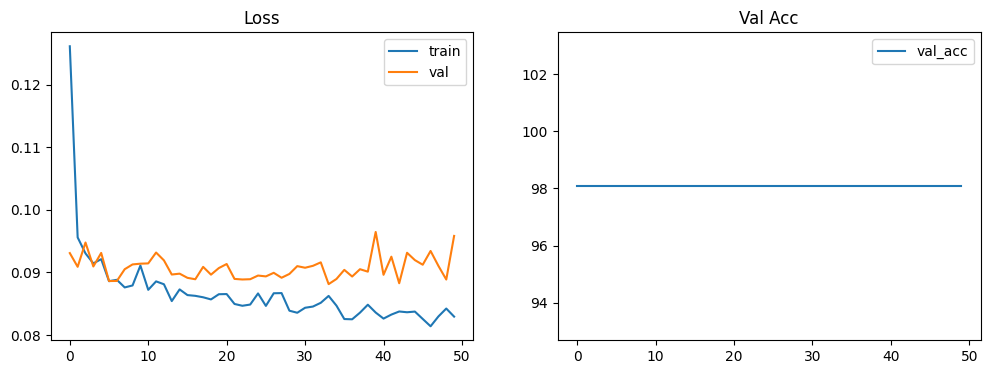

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(train_losses, label="train"); plt.plot(val_losses, label="val"); plt.title("Loss"); plt.legend()
plt.subplot(1,2,2); plt.plot(val_accuracies, label="val_acc"); plt.title("Val Acc"); plt.legend()
plt.show()